In [1]:
# ==============================================================================
# Cell 1: Download files and create opioid.db using sqlite3 and pandas
# ==============================================================================
import sqlite3
import pandas as pd

# URLs matching the Open Case Studies datasets
base_url = "https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/"
table_map = {
    "population": "county_pop_arcos.csv",
    "annual": "county_annual.csv",
    "land": "land_area.csv"
}

# Connect to (and create) the SQLite database file
conn = sqlite3.connect("opioid.db")

# Read each CSV directly from the web and store it as a table in SQLite
for table_name, file_name in table_map.items():
    print(f"Loading {file_name} into table '{table_name}'...")
    df_temp = pd.read_csv(base_url + file_name)
    df_temp.to_sql(table_name, conn, if_exists="replace", index=False)

# Close SQLite connection to complete the "exit sqlite" prompt instruction
conn.close()
print("Created opioid.db with tables: population, annual, land.")

Loading county_pop_arcos.csv into table 'population'...
Loading county_annual.csv into table 'annual'...
Loading land_area.csv into table 'land'...
Created opioid.db with tables: population, annual, land.


In [2]:
# ==============================================================================
# Cell 2: Read tables from opioid.db into Pandas DataFrames
# ==============================================================================
import sqlite3
import pandas as pd

# Open connection to read tables
conn = sqlite3.connect("opioid.db")

# Read the three tables into separate DataFrames
population = pd.read_sql("SELECT * FROM population", conn)
annual = pd.read_sql("SELECT * FROM annual", conn)
land = pd.read_sql("SELECT * FROM land", conn)

# Close connection immediately — wrangling is done directly in pandas
conn.close()

print(f"Loaded shapes -> population: {population.shape}, annual: {annual.shape}, land: {land.shape}")

Loaded shapes -> population: (28265, 11), annual: (27758, 7), land: (3198, 35)


In [3]:
# ==============================================================================
# Cell 3: Data cleaning and merging in Pandas
# ==============================================================================

# 1. Update Montgomery County, AR missing FIPS to 05097
annual["countyfips"] = annual["countyfips"].astype(str)

annual.loc[
    (annual["BUYER_STATE"] == "AR") & (annual["BUYER_COUNTY"] == "MONTGOMERY"),
    "countyfips"
] = "05097"

# 2. Delete rows where BUYER_COUNTY is "NA" or null
annual = annual[annual["BUYER_COUNTY"].notna() & (annual["BUYER_COUNTY"] != "NA")].copy()

# 3. Create land_area with Areaname, STCOU, and LND110210D
lnd_col = "LND110210D" if "LND110210D" in land.columns else [c for c in land.columns if c.startswith("LND")][0]
land_area = land[["Areaname", "STCOU", lnd_col]].copy()
land_area.rename(columns={"STCOU": "countyfips"}, inplace=True)

# 4. Standardize years to integer across dataframes
annual["DOSAGE_UNIT"] = pd.to_numeric(annual["DOSAGE_UNIT"], errors="coerce")
annual["year"] = pd.to_numeric(annual["year"], errors="coerce")
population["year"] = pd.to_numeric(population["year"], errors="coerce")

# Drop any records with missing year in annual or population
annual = annual.dropna(subset=["year"]).copy()
population = population.dropna(subset=["year"]).copy()
annual["year"] = annual["year"].astype(int)
population["year"] = population["year"].astype(int)

# 5. Clean and format countyfips
def format_fips(val):
    if pd.isna(val) or str(val).strip().upper() in ["NA", "NAN", ""]:
        return None
    val_str = str(val).split(".")[0].strip()
    return val_str.zfill(5)

annual["countyfips"] = annual["countyfips"].apply(format_fips)
population["countyfips"] = population["countyfips"].apply(format_fips)
land_area["countyfips"] = land_area["countyfips"].apply(format_fips)

# 6. Left join population with land_area to create county_info
county_info = pd.merge(population, land_area, on="countyfips", how="left")

# 7. Merge annual with county_info
final_merged_df = pd.merge(
    annual,
    county_info,
    on=["countyfips", "year"],
    how="inner",
    suffixes=("", "_pop")
)

print(f"Final merged dataset shape: {final_merged_df.shape}")
final_merged_df.head()

Final merged dataset shape: (26980, 18)


,Unnamed: 0,BUYER_COUNTY,BUYER_STATE,year,count,DOSAGE_UNIT,countyfips,Unnamed: 0_pop,BUYER_COUNTY_pop,BUYER_STATE_pop,STATE,COUNTY,county_name,NAME,variable,population,Areaname,LND110210D
0,1,ABBEVILLE,SC,2006,877,363620.0,45001,2313,ABBEVILLE,SC,45,1,Abbeville,"Abbeville County, South Carolina",B01003_001,25821,"Abbeville, SC",490.48
1,2,ABBEVILLE,SC,2007,908,402940.0,45001,5455,ABBEVILLE,SC,45,1,Abbeville,"Abbeville County, South Carolina",B01003_001,25745,"Abbeville, SC",490.48
2,3,ABBEVILLE,SC,2008,871,424590.0,45001,8597,ABBEVILLE,SC,45,1,Abbeville,"Abbeville County, South Carolina",B01003_001,25699,"Abbeville, SC",490.48
3,4,ABBEVILLE,SC,2009,930,467230.0,45001,11737,ABBEVILLE,SC,45,1,Abbeville,"Abbeville County, South Carolina",B01003_001,25347,"Abbeville, SC",490.48
4,5,ABBEVILLE,SC,2010,1197,539280.0,45001,14877,ABBEVILLE,SC,45,1,Abbeville,"Abbeville County, South Carolina",B01003_001,25643,"Abbeville, SC",490.48


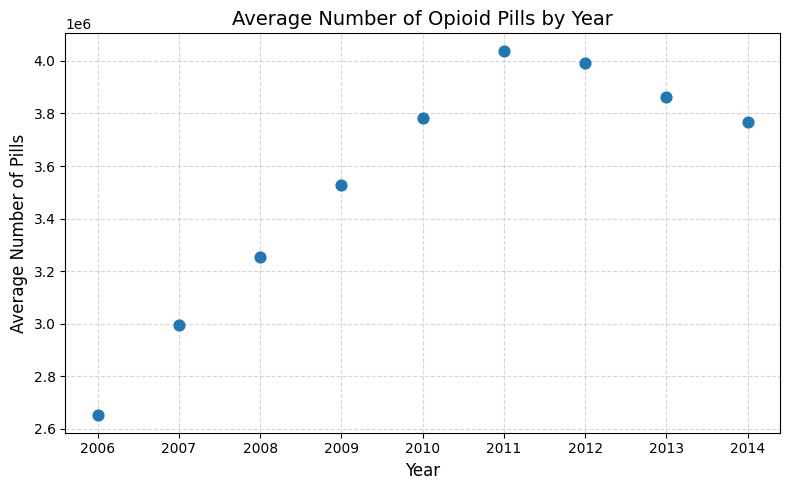

In [4]:
# ==============================================================================
# Cell 4: Scatterplot of average opioid pills by year
# ==============================================================================
import matplotlib.pyplot as plt

# Calculate the mean pills per year
yearly_avg = annual.groupby("year")["DOSAGE_UNIT"].mean().reset_index()

# Build the scatterplot
plt.figure(figsize=(8, 5))
plt.scatter(
    yearly_avg["year"],
    yearly_avg["DOSAGE_UNIT"],
    color="#1f77b4",
    s=60,
    zorder=3
)

# Titles and axis formatting
plt.title("Average Number of Opioid Pills by Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Number of Pills", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)
plt.xticks(yearly_avg["year"].astype(int))

plt.tight_layout()
plt.show()

In [5]:
%%writefile hw4.R
# ==============================================================================
# hw4.R: R Data Wrangling
# ==============================================================================
library(readr)
library(dplyr)
library(stringr)

base_url <- "https://raw.githubusercontent.com/opencasestudies/ocs-bp-opioid-rural-urban/master/data/simpler_import/"

# 1. Read CSV files
population <- read_csv(paste0(base_url, "county_pop_arcos.csv"), show_col_types = FALSE)
annual <- read_csv(paste0(base_url, "county_annual.csv"), show_col_types = FALSE)
land <- read_csv(paste0(base_url, "land_area.csv"), show_col_types = FALSE)

# 2. Clean annual table (fix Montgomery AR, remove NA counties, parse numeric)
annual <- annual %>%
  mutate(countyfips = if_else(BUYER_STATE == "AR" & BUYER_COUNTY == "MONTGOMERY", "05097", countyfips)) %>%
  filter(!is.na(BUYER_COUNTY) & BUYER_COUNTY != "NA") %>%
  mutate(
    DOSAGE_UNIT = as.numeric(DOSAGE_UNIT),
    year = as.integer(year),
    countyfips = str_pad(as.character(countyfips), width = 5, pad = "0")
  )

# 3. Clean land table (select columns and rename STCOU to countyfips)
lnd_col <- names(land)[grepl("^LND", names(land))][1]

land_area <- land %>%
  select(Areaname, countyfips = STCOU, all_of(lnd_col)) %>%
  mutate(countyfips = str_pad(as.character(countyfips), width = 5, pad = "0"))

# 4. Standardize population table
population <- population %>%
  mutate(
    countyfips = str_pad(as.character(countyfips), width = 5, pad = "0"),
    year = as.integer(year)
  )

# 5. Merge tables
county_info_r <- population %>%
  left_join(land_area, by = "countyfips")

final_r_df <- annual %>%
  inner_join(county_info_r, by = c("countyfips", "year"))

print(head(final_r_df))

Overwriting hw4.R


In [6]:
# ==============================================================================
# Cell 5: Call R code from Python using rpy2 and convert to Pandas
# ==============================================================================
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Read the R code from hw4.R
with open("hw4.R", "r") as f:
    r_script = f.read()

# Run the R code inside the embedded R session
ro.r(r_script)

# Convert the resulting R data frame 'final_r_df' into a pandas DataFrame
with localconverter(ro.default_converter + pandas2ri.converter):
    df_from_r = ro.conversion.rpy2py(ro.r["final_r_df"])

# Verify results
print("Converted R object type:", type(df_from_r))
print("Data shape from R:", df_from_r.shape)
df_from_r.head()

Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union




New names:
• `` -> `...1`
New names:
• `` -> `...1`
New names:
• `` -> `...1`
# A tibble: 6 × 18
  ...1.x BUYER_COUNTY.x BUYER_STATE.x  year count DOSAGE_UNIT countyfips ...1.y
   <dbl> <chr>          <chr>         <int> <dbl>       <dbl> <chr>       <dbl>
1      1 ABBEVILLE      SC             2006   877      363620 45001        2313
2      2 ABBEVILLE      SC             2007   908      402940 45001        5455
3      3 ABBEVILLE      SC             2008   871      424590 45001        8597
4      4 ABBEVILLE      SC             2009   930      467230 45001       11737
5      5 ABBEVILLE      SC             2010  1197      539280 45001       14877
6      6 ABBEVILLE      SC             2011  1327      566560 45001       18017
# ℹ 10 more variables: BUYER_COUNTY.y <chr>, BUYER_STATE.y <chr>, STATE <dbl>,
#   COUNTY <dbl>, county_name <chr>, NAME <chr>, variable <chr>,
#   population <dbl>, Areaname <chr>, LND010190F <dbl>
Converted R object type: <class 'pandas.core.frame.DataFrame'>
D

,...1.x,BUYER_COUNTY.x,BUYER_STATE.x,year,count,DOSAGE_UNIT,countyfips,...1.y,BUYER_COUNTY.y,BUYER_STATE.y,STATE,COUNTY,county_name,NAME,variable,population,Areaname,LND010190F
1,1.0,ABBEVILLE,SC,2006,877.0,363620.0,45001,2313.0,ABBEVILLE,SC,45.0,1.0,Abbeville,"Abbeville County, South Carolina",B01003_001,25821.0,"Abbeville, SC",0.0
2,2.0,ABBEVILLE,SC,2007,908.0,402940.0,45001,5455.0,ABBEVILLE,SC,45.0,1.0,Abbeville,"Abbeville County, South Carolina",B01003_001,25745.0,"Abbeville, SC",0.0
3,3.0,ABBEVILLE,SC,2008,871.0,424590.0,45001,8597.0,ABBEVILLE,SC,45.0,1.0,Abbeville,"Abbeville County, South Carolina",B01003_001,25699.0,"Abbeville, SC",0.0
4,4.0,ABBEVILLE,SC,2009,930.0,467230.0,45001,11737.0,ABBEVILLE,SC,45.0,1.0,Abbeville,"Abbeville County, South Carolina",B01003_001,25347.0,"Abbeville, SC",0.0
5,5.0,ABBEVILLE,SC,2010,1197.0,539280.0,45001,14877.0,ABBEVILLE,SC,45.0,1.0,Abbeville,"Abbeville County, South Carolina",B01003_001,25643.0,"Abbeville, SC",0.0
